In [1]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 26.99it/s]


Numba compilation complete!


In [4]:
#initial file processing
workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
titledpath = homecomp
openPath = titledpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"


In [5]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

[f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Fira Mono"

In [6]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

## Function

In [13]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

def wrap_labels(ax, width, break_long_words=False):
    import textwrap
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

## Code

## Combined files

In [14]:
newfile2 = openPath + "Compilation with delta\\2025meandiffcollection\\"
files2 = os.listdir(newfile2)
totalfile = pd.DataFrame()

for n in files2:
    
    openfile = pd.read_csv(newfile2 + n)
    nameofmbon = n.split(" ")[0] 
    openfile['responder'] = n.split(" ")[2]
    totalfile = pd.concat([totalfile, openfile], axis = 0).reset_index(drop=True)

lstofallvariables = []
for n in totalfile.columns.to_list()[1:-1]:
    lstofallvariables.append(n.split("_")[0])
lstnamings= list(set(lstofallvariables))

totalfile['genotypeandresponder'] = totalfile["MBON"] + "_" + totalfile['responder']   #has bootstraps


In [15]:
#only delta-g
onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)
onlymeans

,MBON,fallprop_deltag,fallnumber_deltag,speed_deltag,time_deltag,height_deltag,displacement_deltag,bspeed_deltag,pausepos_deltag,displacementbetweenpause_deltag,maxvelocity_deltag,straightindex_deltag,ascent_deltag,descent_deltag,meanpause_deltag,meanbout_deltag,pause_deltag,bout_deltag,responder,genotypeandresponder
0,MB011B,0.081,0.090,-0.028,0.262,0.243,-0.017,0.166,0.201,0.304,-0.242,0.104,0.089,-0.051,0.319,0.126,-0.114,-0.095,ACR,MB011B_ACR
1,MB011B,0.140,-0.150,-0.058,-0.054,0.165,-0.035,0.034,0.382,0.202,0.782,0.532,0.003,-0.133,0.117,0.082,-0.290,-0.303,Chrimson2,MB011B_Chrimson2
2,MB018B,-0.175,-0.339,-0.149,-0.056,-0.242,-0.134,-0.040,-0.433,0.309,-1.405,0.892,-0.590,0.394,0.550,0.315,-0.430,-0.424,ACR,MB018B_ACR
3,MB018B,-0.022,0.076,-0.350,0.118,0.293,-0.400,0.184,0.336,0.012,0.412,0.210,-0.152,-0.453,0.523,0.146,-0.372,-0.384,Chrimson2,MB018B_Chrimson2
4,MB027B,-0.063,0.014,-0.300,0.178,0.127,-0.301,-0.109,-0.039,0.027,-0.496,-0.037,-0.230,-0.244,0.260,0.126,0.013,-0.019,ACR,MB027B_ACR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,SS97567,-0.102,-0.125,-0.165,-0.412,-0.291,-0.176,0.143,-0.121,0.176,-0.428,0.098,0.045,-0.251,0.477,0.297,-0.549,-0.506,Chrimson2,SS97567_Chrimson2
91,Th-Gal4,-0.032,-0.273,-0.527,0.190,-0.008,-0.670,-0.102,-0.154,-0.219,-0.068,-0.738,-0.517,-0.513,0.424,-0.038,-0.072,-0.177,ACR,Th-Gal4_ACR
92,Th-Gal4,0.603,1.547,-0.304,-0.207,-0.390,-0.499,-0.703,-0.551,-0.698,-0.132,0.330,0.141,-0.909,-0.479,0.029,0.378,0.361,Chrimson2,Th-Gal4_Chrimson2
93,VT999036,-0.060,-0.053,-1.768,-0.544,-0.346,-1.752,-0.046,-0.597,-0.796,-1.606,0.771,-1.724,-1.009,1.415,-0.574,-0.916,-1.027,ACR,VT999036_ACR


In [16]:
#lobe location

files2 = os.listdir(newfile2)

MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

#reading mbonlist file
directorynew = os.path.dirname(os.path.dirname(openPath)) #goes up one directory
fileinnewdirc = os.listdir(directorynew)

for file_no2 in fileinnewdirc:
    if ".csv" in file_no2:
        ff = os.path.join(directorynew, file_no2)
        csvfile = pd.read_csv(ff)

csvfile = csvfile.astype('string')

for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
    csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

lobelocation = pd.DataFrame()

for m in MBONList:
    lobeloc = pd.DataFrame()
    unqlist = []
    lobeloc['MBON'] = [m]
    loclst = find_number(csvfile, m, "Lobe")
    mbonlst = find_number(csvfile, m, "MBON number").strip()
    ntlst = find_number(csvfile, m, "Neurotransmitter")
    lobeloc['Lobe_location'] = [loclst]
    lobeloc['MBON number'] = [mbonlst]
    lobeloc['Neurotransmitter'] = [ntlst]
    
    lobelocation = pd.concat([lobelocation, lobeloc])

lobelocation = lobelocation.reset_index(drop=True)

## Lin Reg via metrics (not updated)

## lin reg of metrics

In [92]:
responder = "Chrimson2"

onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallprop_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'pause_deltag', 'meanpause_deltag',
                   'responder', 'genotypeandresponder']

eightmetrics = pd.DataFrame()
for p in specificmetrics:
    eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
eightmetrics = eightmetrics.reset_index(drop=True)



if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="Chrimson2"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="ACR"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

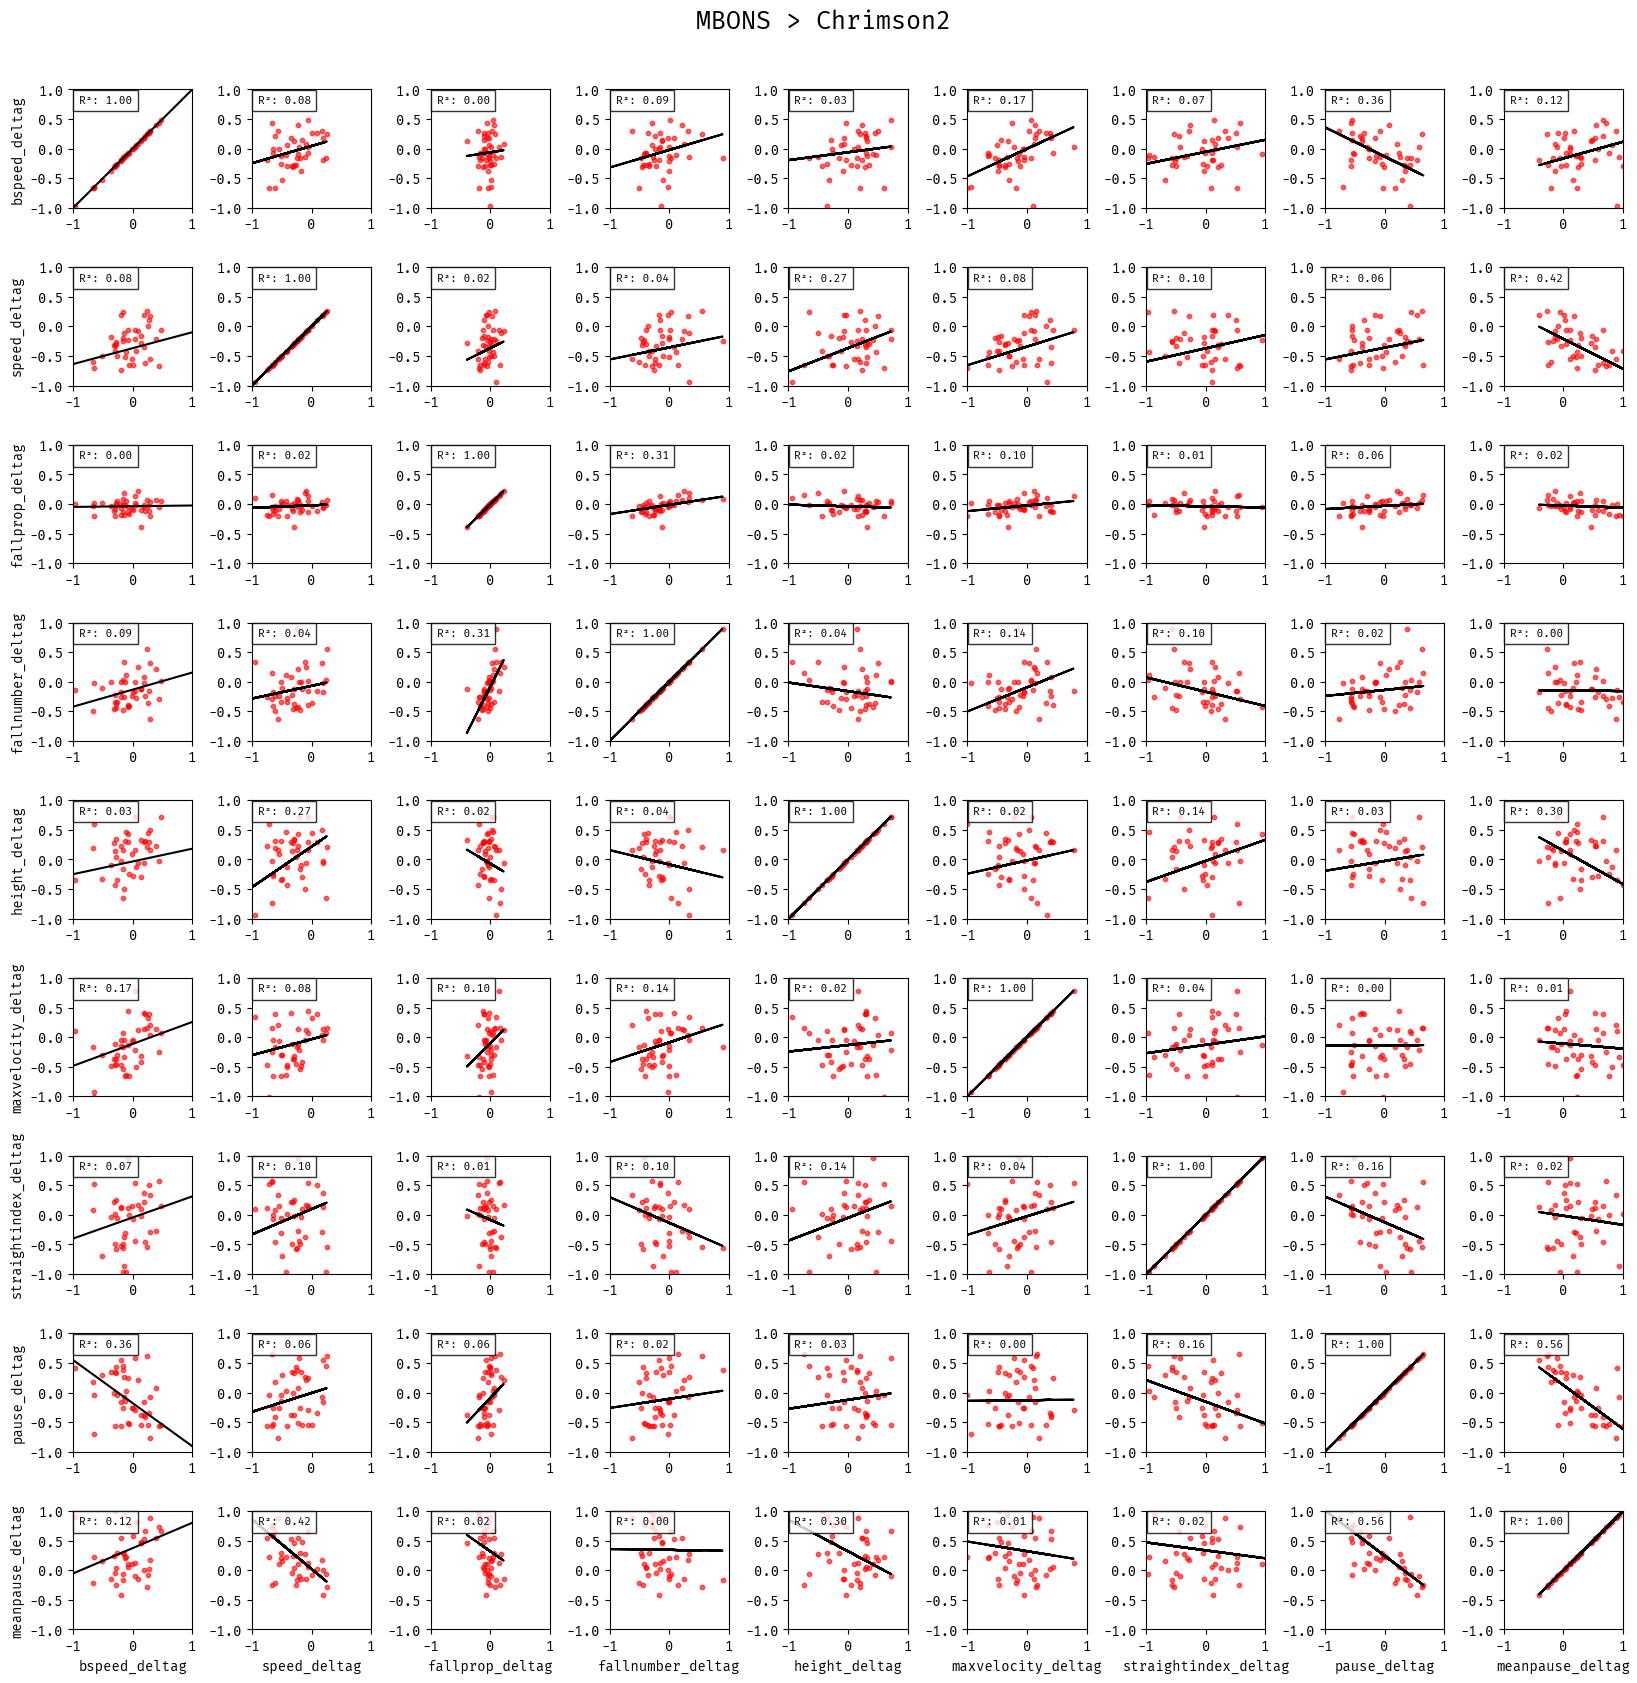

In [94]:
# Create a figure and axis grid
from scipy.stats import linregress, pearsonr, t

fig, axes = plt.subplots(9, 9, figsize=(20, 20), gridspec_kw={'wspace': 0.5, 'hspace': 0.5})

df_linreg = df_specificmbon.drop(['responder', 'genotypeandresponder', 'MBON'], axis =1)

# Plot scatter plots for every combination of metrics
for i in range(len(df_linreg.columns)):
    for j in range(len(df_linreg.columns)):
        ax = axes[i, j]
        x = df_linreg.iloc[:, j]
        y = df_linreg.iloc[:, i]
        ax.scatter(x, y, alpha=0.6, c = "r", s=10)  # Scatter plot
        
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        # Add line of best fit
        ax.plot(x, slope * x + intercept, color='black')  # Regression line
        
        # Annotate with R² value
        ax.text(0.05, 0.95, f"R²: {r_value**2:.2f}", 
                transform=ax.transAxes, fontsize=8, verticalalignment='top', 
                bbox=dict(facecolor='white', alpha=0.8))
        
        # Set axis labels
        if i == 8:  # Add x-axis labels only for the bottom row
            ax.set_xlabel(df_linreg.columns[j])
        if j == 0:  # Add y-axis labels only for the first column
            ax.set_ylabel(df_linreg.columns[i])

        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
# Remove empty space between subplots
plt.tight_layout()

fig.suptitle("MBONS > " + responder, fontsize = 18, y = 0.92)

# Show the plot
plt.show()

## lin reg single metric

In [106]:
responder = "ACR"

onlymeans = totalfile.loc[:, ~totalfile.columns.str.endswith('_bootstrap')].drop_duplicates().reset_index(drop=True)

mbononly=onlymeans[~onlymeans['MBON'].isin(['R58', 'Th-Gal4'])]

specificmetrics = ['MBON', 'bspeed_deltag', 'speed_deltag', 'fallprop_deltag', 'fallnumber_deltag',  'height_deltag', 'maxvelocity_deltag', 'straightindex_deltag', 'pause_deltag', 'meanpause_deltag',
                   'responder', 'genotypeandresponder']

eightmetrics = pd.DataFrame()
for p in specificmetrics:
    eightmetrics = pd.concat([eightmetrics, mbononly[p]], axis =1) 
eightmetrics = eightmetrics.reset_index(drop=True)

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="Chrimson2"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = eightmetrics[eightmetrics['responder']=="ACR"].sort_values(by = "bspeed_deltag", ascending=True).reset_index(drop=True)

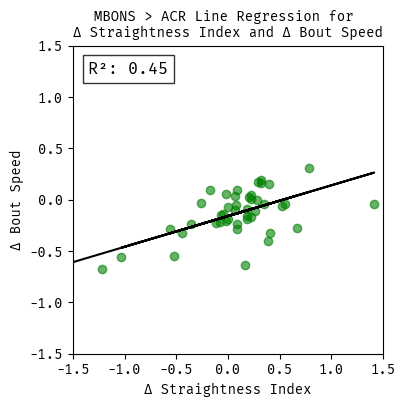

In [115]:
from scipy.stats import linregress
x = df_specificmbon['meanpause_deltag']
y = df_specificmbon['bspeed_deltag']

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Create the scatter plot
plt.figure(figsize=(4, 4))
plt.scatter(x, y, c = 'g', alpha=0.6, label='Data Points')  # Scatter plot

# Add the line of best fit
plt.plot(x, slope * x + intercept, color='black', label='Line of Best Fit')  # Regression line

# Annotate with R² value
plt.text(0.05, 0.95, f"R²: {r_value**2:.2f}", 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', 
         bbox=dict(facecolor='white', alpha=0.8))

# Add labels and title
xtitle = 'Δ Straightness Index'
ytitle = 'Δ Bout Speed'
plt.xlabel(xtitle)
plt.ylabel(ytitle)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.title('MBONS > ' + responder + " Line Regression for \n" + xtitle + " and " + ytitle, fontsize = 10)


# Show the plot
plt.show()

In [ ]:
# import scipy.stats
# fig2, ax2 = plt.subplots(nrows = 1, ncols = 9, figsize = (20, 3), sharey = True, layout= 'constrained')
# labels = [ ' \n '.join(wrap(l, 12)) for l in df_specificmbon.columns[:-2].tolist()]

# for c,(n,leg) in enumerate(zip(df_specificmbon.columns[:-2].tolist(),8*[False]+[True])):  #by number of metrics
#     spare = pd.DataFrame()
#     spare[n] = matchinglobesets(df_specificmbon, lobelocation)[n]
#     spare['NT'] = matchinglobesets(df_specificmbon, lobelocation)['Neurotransmitter']
#     sns.regplot(x="Chrimson2", y="Chrimson2", data=spare, ci = 95, scatter = False, line_kws={"color": "black", 'lw': 1.5}, ax=ax2[c]) 
#     sns.scatterplot(x="Chrimson2", y="Chrimson2", data=spare, hue='NT', s = 3, ax = ax2[c], legend = leg)
#     ax2[c].set_xlim([-2,2])
#     ax2[c].set_ylim([-2,2])
#     ax2[c].set_xlabel(labels[c])
#     ax2[c].set_ylabel("")
    
#     #pearsons correlation
#     pearsonscorrelation = scipy.stats.pearsonr(df_specificmbon[n], df_specificmbon[n]) #correlation instead of linear regression: trying to find the relationship rather than causation    
#     civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
#     civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]   
#     ax2[c].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.45, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 8)

# fig2.supxlabel("ACR", weight = "bold")
# fig2.supylabel("Chrimson2", weight = "bold")
# fig2.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

# new_labels = ['Glutamate', 'Acetylcholine', 'GABA', 'Acetylcholine, GABA']
# legend_handles, _= ax2[c].get_legend_handles_labels()
# lgd = fig2.legend(legend_handles, new_labels, 
#           bbox_to_anchor=(1,1), ncol = 4, frameon = False)
# ax2[c].get_legend().set_visible(False)

# #plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheck.png", dpi = 1200, bbox_inches='tight')

In [ ]:
import scipy.stats
fig7, ax7 = plt.subplots(nrows = 8, ncols = 8, figsize = (10, 10), sharey = True, sharex = True, layout= 'constrained')

for name,row,col in zip(dfreg_a['MBON'], 5*list(range(0,5)), 5*[0]+5*[1]+5*[2]+5*[3]+ 5*[4] +5*[5]):
    df_meltedreg = pd.melt(df_lregmbon[(df_lregmbon['MBON'] == name)], id_vars = ['responder', "MBON"])   
    df_a1= df_meltedreg[(df_meltedreg['responder'] == 'Cr2')]
    df_c1=df_meltedreg[(df_meltedreg['responder'] == 'ACR')]
    
    ax7[row][col].scatter(x= df_a1['value'], y = df_c1['value'],
                color='grey',
                edgecolors="r",
                alpha=0.8,
                s=30)
    
    sns.regplot(x= df_a1['value'], y = df_c1['value'],
                scatter=False,
                line_kws={'lw':1}, 
                color="k",
                ax=ax7[row][col],
                truncate=False)

    ax7[row][col].set(xlabel=None)
    ax7[row][col].set(ylabel=None)
    ax7[row][col].set_ylim(-2.1,2.1)  
    ax7[row][col].set_xlim(-2.1,2.1) 
    ax7[row][col].set_title(name, fontsize = 12)

    
    #pearsons correlation
    pearsonscorrelation = scipy.stats.pearsonr(df_a1['value'], df_c1['value']) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
    civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]
    ax7[row][col].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.55, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 9)

    
fig7.supxlabel("ACR", weight = "bold")
fig7.supylabel("Chrimson2", weight = "bold")
fig7.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheckMBON.png", dpi = 1200, bbox_inches='tight')

## Lin regression grouped by circles (not updated)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from matplotlib.patches import Ellipse
# fig3, axthree = plt.subplots(nrows = 1, ncols = 9, figsize = (20, 3), sharey = True, layout= 'constrained')


for c,(n,leg) in enumerate(zip(dfreg_a.columns[:-2].tolist(),8*[False]+[True])):
    fig3, axthree = plt.subplots(figsize = (4, 4))
    
    spare = pd.DataFrame()
    spare["ACR"] = matchinglobesets(dfreg_a, lobelocation)[n]
    spare['Chrimson2'] = matchinglobesets(dfreg_c, lobelocation)[n]
    spare['NT'] = matchinglobesets(dfreg_c, lobelocation)['Neurotransmitter']
    
    #kmeans
    kmeans = SpectralClustering(n_clusters=3)
    clusters = kmeans.fit_predict(spare.iloc[:,0:2])
    cluster = ['k-means_c_' + str(c) for c in clusters]
    X = spare.iloc[:,0:2]
    ogdots = ['#d90429','#f7b267', '#89fc00', '#735751'] #neurotransmitters : red, orange, green, brown
    clusterdots = ["#03045e", '#0077b6', "#00b4d8", "#90e0ef"] #clustering patterns :blue
    
    #neto = sns.scatterplot(x="ACR", y="Chrimson2", data=spare, hue='NT', s = 80, edgecolor = "none", palette = ogdots , legend = True)
    sns.scatterplot(x="ACR", y="Chrimson2", data=X.iloc[:,0:2].assign(cluster = cluster), hue='cluster', palette = clusterdots, legend = False, s = 40, edgecolor = "none")
           
    axthree.set_xlim([-2,2])
    axthree.set_ylim([-2,2])
    axthree.set_xlabel("")
    axthree.set_ylabel("")
    plt.yticks(fontsize=6)
    plt.xticks(fontsize=6)
    

    fig3.supxlabel("ACR", fontsize = 8,  weight = "bold")
    fig3.supylabel("Chrimson2", fontsize = 8, weight = "bold")
    fig3.suptitle(n, fontsize = 12, weight="bold")
    plt.legend(loc=2, prop={'size': 8})
#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheck.png", dpi = 1200, bbox_inches='tight')

In [ ]:
df_completeresponder = pd.concat([dfreg_a, dfreg_c])
df_lregmbon = df_completeresponder.sort_values(['MBON']).reset_index(drop=True)

In [ ]:
import scipy.stats
fig7, ax7 = plt.subplots(nrows = 5, ncols = 5, figsize = (10, 10), sharey = True, sharex = True, layout= 'constrained')
for name,row,col in zip(dfreg_a['MBON'], 5*list(range(0,5)), 5*[0]+5*[1]+5*[2]+5*[3]+ 5*[4] +5*[5]):
    df_meltedreg = pd.melt(df_lregmbon[(df_lregmbon['MBON'] == name)], id_vars = ['responder', "MBON"])   
    df_a1= df_meltedreg[(df_meltedreg['responder'] == 'Cr2')]
    df_c1=df_meltedreg[(df_meltedreg['responder'] == 'ACR')]
    
    ax7[row][col].scatter(x= df_a1['value'], y = df_c1['value'],
                color='grey',
                edgecolors="r",
                alpha=0.8,
                s=30)
    
    sns.regplot(x= df_a1['value'], y = df_c1['value'],
                scatter=False,
                line_kws={'lw':1}, 
                color="k",
                ax=ax7[row][col],
                truncate=False)

    ax7[row][col].set(xlabel=None)
    ax7[row][col].set(ylabel=None)
    ax7[row][col].set_ylim(-2.1,2.1)  
    ax7[row][col].set_xlim(-2.1,2.1) 
    ax7[row][col].set_title(name, fontsize = 12)

    
    #pearsons correlation
    pearsonscorrelation = scipy.stats.pearsonr(df_a1['value'], df_c1['value']) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow = pearsonscorrelation.confidence_interval(confidence_level=0.95)[0] 
    civalhigh = pearsonscorrelation.confidence_interval(confidence_level=0.95)[1]
    ax7[row][col].annotate("Coeff:" + str(round(pearsonscorrelation[0],3)) + "\nCI:" + str(round(civallow,3)) + ", " + str(round(civalhigh,3)), (0.55, 0.8), ha = "left", xycoords = 'axes fraction', fontsize = 9)

    
fig7.supxlabel("ACR", weight = "bold")
fig7.supylabel("Chrimson2", weight = "bold")
fig7.suptitle("Linear regression with Pearson's coeff", fontsize = 16, weight="bold")

#plt.savefig(openPath + "images\\" + date + "_" + responder + "_bidirectionalitycheckMBON.png", dpi = 1200, bbox_inches='tight')